---
## Setup & data reload

This notebook does **not** depend on `analysis.ipynb`'s kernel. It rebuilds `expr_clean` and `meta_clean`
from the cached GEO download using the identical pipeline (log2 → drop AFFX controls → probe-to-gene
collapse by highest mean → drop samples whose mean inter-sample *r* is more than 2 SD below the cohort mean).

An `assert` at the end fails loudly if the rebuild does not reproduce the expected 13,237 × 152 matrix.

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse

ORDER     = ["Normal_PC", "MGUS", "SMM", "MM_New", "MM_Relapse"]
PALETTE   = dict(zip(ORDER, sns.color_palette("Set2", len(ORDER))))
STAGE_COL = "stage"
SEED      = 42

os.makedirs("results/ml", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)
print("Libraries OK")

Libraries OK


In [2]:
gse = GEOparse.get_GEO("GSE6477", destdir="data/geo/", silent=True)

parts = {
    name: gsm.table.set_index("ID_REF")["VALUE"].rename(name)
    for name, gsm in gse.gsms.items()
    if gsm.table is not None and not gsm.table.empty
}
expr = pd.DataFrame(parts).astype(float)

meta = pd.DataFrame({
    "source": {n: g.metadata.get("source_name_ch1", [""])[0] for n, g in gse.gsms.items()},
}).reindex(expr.columns)

_map = {"normal": "Normal_PC", "mgus": "MGUS", "smoldering": "SMM",
        "newly diagnosed": "MM_New", "relapsed": "MM_Relapse"}
def _clean(src):
    s = str(src).lower()
    for key, label in _map.items():
        if key in s:
            return label
    return "Unknown"
meta[STAGE_COL] = meta["source"].map(_clean)

expr_log = np.log2(expr + 1)
expr_log = expr_log[~expr_log.index.str.startswith("AFFX")]

annot      = gse.gpls["GPL96"].table.copy()
probe2gene = (annot.set_index("ID")["Gene Symbol"].fillna("")
              .str.split(" /// ").str[0].str.strip())

gene_labels = probe2gene.reindex(expr_log.index).fillna("")
keep        = gene_labels != ""

tmp          = expr_log[keep].copy()
tmp.index    = gene_labels[keep]
tmp["_mean"] = tmp.mean(axis=1)
tmp          = tmp.sort_values("_mean", ascending=False)
expr_genes   = tmp[~tmp.index.duplicated(keep="first")].drop(columns="_mean")

mean_r  = expr_genes.corr().mean()
to_drop = mean_r[mean_r < mean_r.mean() - 2 * mean_r.std()].index.tolist()

expr_clean = expr_genes.drop(columns=to_drop)
meta_clean = meta.reindex(expr_clean.columns)

print(f"Matrix          : {expr_clean.shape[0]:,} genes x {expr_clean.shape[1]} samples")
print(f"Outliers dropped: {len(to_drop)}")

assert expr_clean.shape == (13237, 152), f"Rebuild mismatch: got {expr_clean.shape}, expected (13237, 152)"
assert meta_clean[STAGE_COL].isin(ORDER).all(), "Some samples failed stage mapping"
assert list(meta_clean.index) == list(expr_clean.columns), "meta/expr sample order mismatch"
print("Rebuild matches analysis.ipynb")
print()
print(meta_clean[STAGE_COL].value_counts()[ORDER].to_string())

Matrix          : 13,237 genes x 152 samples
Outliers dropped: 10
Rebuild matches analysis.ipynb

stage
Normal_PC     14
MGUS          19
SMM           20
MM_New        73
MM_Relapse    26


---
## Task framing & baselines

**A model is only informative if it beats the majority-class baseline.** With 73 of 152 samples in
`MM_New`, a model that blindly guesses `MM_New` every single time already scores ~48% on the 5-class task.
Any accuracy near that number means the model learned nothing.

Two tasks are run separately, because they are very different in difficulty:

| Task | Question | Why split it out |
|---|---|---|
| **Binary** | Normal_PC vs. any disease stage | The UMAP showed Normal_PC forms its own island — this should be learnable |
| **5-class** | Which of the 5 stages? | The UMAP showed MGUS/SMM/MM_New/MM_Relapse overlap heavily — expect this to be hard |

Two metrics are reported. **Accuracy** is what fraction of samples were called correctly, but it flatters
a model on imbalanced data. **Balanced accuracy** averages the per-class recall, so ignoring a small class
is penalised — it is the more honest number here.

In [3]:
y_stage = meta_clean[STAGE_COL].values
counts  = pd.Series(y_stage).value_counts().reindex(ORDER)

n_total    = counts.sum()
n_normal   = counts["Normal_PC"]
n_disease  = n_total - n_normal
maj_5class = counts.max() / n_total
maj_binary = max(n_disease, n_normal) / n_total

print("Class distribution")
print("-" * 34)
for stg in ORDER:
    print(f"  {stg:<12s} {counts[stg]:3d}   ({counts[stg]/n_total:5.1%})")
print(f"  {'TOTAL':<12s} {n_total:3d}")
print()
print("Majority-class baselines (the bar to beat)")
print("-" * 44)
print(f"  5-class accuracy   : {maj_5class:.1%}   (always guess '{counts.idxmax()}')")
print(f"  5-class balanced   : {1/len(ORDER):.1%}   (a constant guess scores 1/5 balanced)")
print(f"  Binary  accuracy   : {maj_binary:.1%}   (always guess 'Disease')")
print(f"  Binary  balanced   : {0.5:.1%}")

Class distribution
----------------------------------
  Normal_PC     14   ( 9.2%)
  MGUS          19   (12.5%)
  SMM           20   (13.2%)
  MM_New        73   (48.0%)
  MM_Relapse    26   (17.1%)
  TOTAL        152

Majority-class baselines (the bar to beat)
--------------------------------------------
  5-class accuracy   : 48.0%   (always guess 'MM_New')
  5-class balanced   : 20.0%   (a constant guess scores 1/5 balanced)
  Binary  accuracy   : 90.8%   (always guess 'Disease')
  Binary  balanced   : 50.0%


---
## clustering

Clustering is given **no stage labels at all**. If the 5 stages are genuinely distinct expression states,
an unsupervised algorithm should rediscover them on its own.

**Adjusted Rand Index (ARI)** scores the agreement between the clusters found and the true stages:
`1.0` = perfect match, `0.0` = no better than random. **Silhouette** measures how tight and well-separated
the clusters are, judged *without* labels — it tells us how many groups the data naturally supports,
which need not be 5.

Selecting the top 5,000 most variable genes uses no label information, so it introduces no leakage.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             normalized_mutual_info_score)

N_TOP   = 5_000
top_var = expr_clean.var(axis=1).nlargest(N_TOP).index
X_clust = StandardScaler().fit_transform(expr_clean.loc[top_var].T.values)

print(f"Clustering input: {X_clust.shape[0]} samples x {X_clust.shape[1]} genes")
print()

rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(X_clust)
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X_clust)
    rows.append({
        "k":              k,
        "silhouette_km":  silhouette_score(X_clust, km.labels_),
        "ARI_km":         adjusted_rand_score(y_stage, km.labels_),
        "NMI_km":         normalized_mutual_info_score(y_stage, km.labels_),
        "ARI_ward":       adjusted_rand_score(y_stage, hc.labels_),
    })

sweep = pd.DataFrame(rows).set_index("k")
print("k sweep (ARI/NMI compare clusters against the true stage labels)")
print(sweep.round(3).to_string())
print()
print(f"Best silhouette at k={sweep['silhouette_km'].idxmax()} "
      f"({sweep['silhouette_km'].max():.3f})")
print(f"Best ARI vs stage at k={sweep['ARI_km'].idxmax()} "
      f"({sweep['ARI_km'].max():.3f})")
sweep.to_csv("results/ml/clustering_k_sweep.csv")

Clustering input: 152 samples x 5000 genes

k sweep (ARI/NMI compare clusters against the true stage labels)
   silhouette_km  ARI_km  NMI_km  ARI_ward
k                                         
2          0.038   0.035   0.105    -0.051
3          0.031   0.124   0.219     0.064
4          0.026   0.094   0.244     0.102
5          0.025   0.070   0.196     0.116
6          0.022   0.144   0.259     0.104
7          0.021   0.090   0.241     0.080
8          0.020   0.097   0.271     0.094

Best silhouette at k=2 (0.038)
Best ARI vs stage at k=6 (0.144)


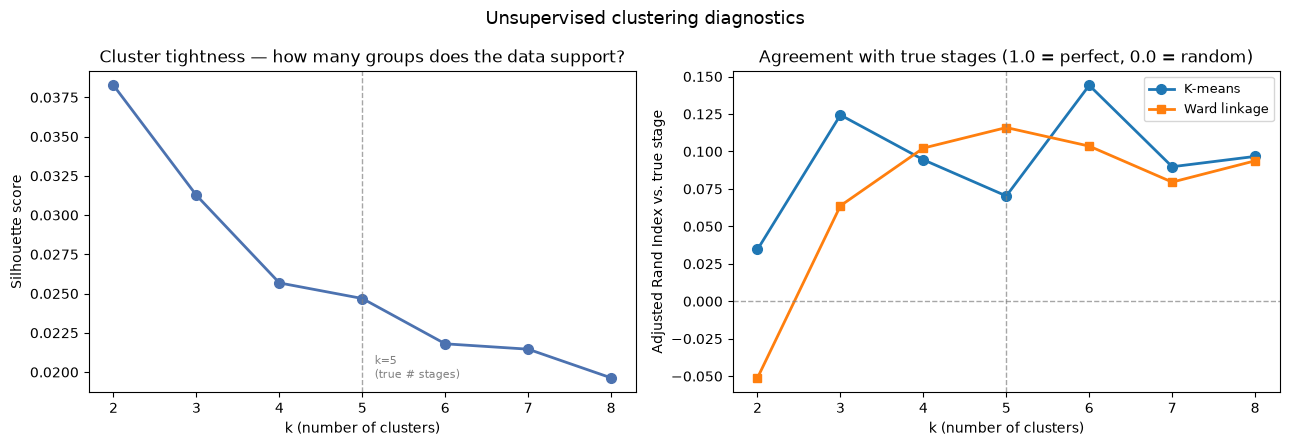

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(sweep.index, sweep["silhouette_km"], "-o", color="#4C72B0", lw=2, ms=7)
axes[0].axvline(5, color="grey", ls="--", lw=1, alpha=0.7)
axes[0].annotate("k=5\n(true # stages)", xy=(5, axes[0].get_ylim()[0]),
                 xytext=(5.15, sweep["silhouette_km"].min()), fontsize=8, color="grey")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Silhouette score")
axes[0].set_title("Cluster tightness — how many groups does the data support?")

axes[1].plot(sweep.index, sweep["ARI_km"],   "-o", lw=2, ms=7, label="K-means")
axes[1].plot(sweep.index, sweep["ARI_ward"], "-s", lw=2, ms=6, label="Ward linkage")
axes[1].axhline(0, color="grey", ls="--", lw=1, alpha=0.7)
axes[1].axvline(5, color="grey", ls="--", lw=1, alpha=0.7)
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Adjusted Rand Index vs. true stage")
axes[1].set_title("Agreement with true stages (1.0 = perfect, 0.0 = random)")
axes[1].legend(fontsize=9)

plt.suptitle("Unsupervised clustering diagnostics", fontsize=13)
plt.tight_layout()
plt.savefig("results/figures/ml_clustering_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

K-means (k=5) clusters vs. true stage — counts
K-means cluster   0  1   2   3   4
True stage                        
Normal_PC        13  0   0   0   1
MGUS              3  2   0   3  11
SMM               3  1   1   6   9
MM_New            3  9  17  20  24
MM_Relapse        0  2  13   4   7

ARI: 0.070
NMI: 0.196

Read this as: does each row concentrate into one column? If a row spreads across
many columns, that stage has no distinct expression state of its own.


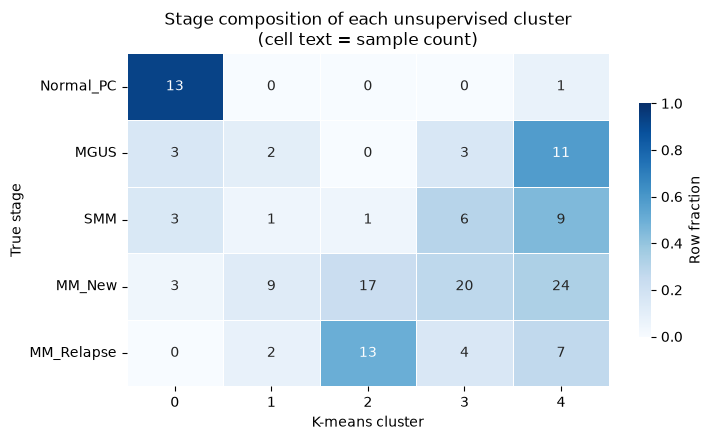

In [6]:
km5 = KMeans(n_clusters=5, n_init=20, random_state=SEED).fit(X_clust)

ct = pd.crosstab(pd.Series(y_stage, name="True stage"),
                 pd.Series(km5.labels_, name="K-means cluster")).reindex(ORDER)

print("K-means (k=5) clusters vs. true stage — counts")
print(ct.to_string())
print()
print(f"ARI: {adjusted_rand_score(y_stage, km5.labels_):.3f}")
print(f"NMI: {normalized_mutual_info_score(y_stage, km5.labels_):.3f}")
print()
print("Read this as: does each row concentrate into one column? If a row spreads across")
print("many columns, that stage has no distinct expression state of its own.")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.heatmap(ct.div(ct.sum(axis=1), axis=0), cmap="Blues", vmin=0, vmax=1,
            annot=ct.values, fmt="d", linewidths=0.6, linecolor="white",
            cbar_kws={"label": "Row fraction", "shrink": 0.7}, ax=ax)
ax.set_title("Stage composition of each unsupervised cluster\n(cell text = sample count)")
plt.tight_layout()
plt.savefig("results/figures/ml_kmeans_crosstab.png", dpi=150, bbox_inches="tight")
plt.show()

ct.to_csv("results/ml/kmeans_k5_crosstab.csv")

---
## Supervised: Normal vs. Disease

**How leakage is avoided.** `StandardScaler` sits inside a `Pipeline`, so it is re-fit on each training
fold only and never sees the held-out samples. No gene filtering is applied before cross-validation —
all 13,237 genes go in and L2 regularisation handles the fact that genes vastly outnumber samples
(*p* ≫ *n*). Selecting genes by their association with stage *before* splitting would leak labels into
the features and inflate every score that follows.

`class_weight="balanced"` stops both models from ignoring the 14 Normal_PC samples in favour of the
138 disease samples. All reported numbers come from `cross_val_predict`, so every prediction was made
by a model that never saw that sample during training.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, balanced_accuracy_score)

X_all = expr_clean.T.values                                       # 152 x 13,237
y_bin = (meta_clean[STAGE_COL] != "Normal_PC").astype(int).values  # 1 = disease

MODELS = {
    "LogReg (L2)": Pipeline([
        ("sc",  StandardScaler()),
        ("clf", LogisticRegression(C=0.1, max_iter=5000,
                                   class_weight="balanced", random_state=SEED)),
    ]),
    "RandomForest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=500, class_weight="balanced",
                                        random_state=SEED, n_jobs=-1)),
    ]),
}

cv_bin  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
bin_out = {}

for name, pipe in MODELS.items():
    prob = cross_val_predict(pipe, X_all, y_bin, cv=cv_bin, method="predict_proba")[:, 1]
    pred = (prob >= 0.5).astype(int)
    bin_out[name] = {"prob": prob, "pred": pred}

    print(f"--- {name} ---")
    print(f"  Accuracy          : {(pred == y_bin).mean():6.1%}   (baseline {maj_binary:.1%})")
    print(f"  Balanced accuracy : {balanced_accuracy_score(y_bin, pred):6.1%}   (baseline 50.0%)")
    print(f"  ROC AUC           : {roc_auc_score(y_bin, prob):6.3f}   (baseline 0.500)")
    tn, fp, fn, tp = confusion_matrix(y_bin, pred).ravel()
    print(f"  Normal_PC found   : {tn}/{tn+fp}      Disease found: {tp}/{tp+fn}")
    print()

--- LogReg (L2) ---
  Accuracy          :  99.3%   (baseline 90.8%)
  Balanced accuracy :  96.4%   (baseline 50.0%)
  ROC AUC           :  1.000   (baseline 0.500)
  Normal_PC found   : 13/14      Disease found: 138/138

--- RandomForest ---
  Accuracy          :  99.3%   (baseline 90.8%)
  Balanced accuracy :  96.4%   (baseline 50.0%)
  ROC AUC           :  1.000   (baseline 0.500)
  Normal_PC found   : 13/14      Disease found: 138/138



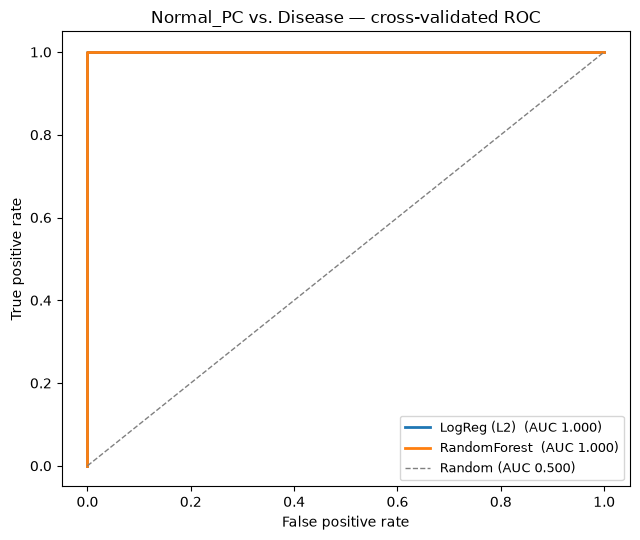

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for name, res in bin_out.items():
    fpr, tpr, _ = roc_curve(y_bin, res["prob"])
    auc = roc_auc_score(y_bin, res["prob"])
    ax.plot(fpr, tpr, lw=2, label=f"{name}  (AUC {auc:.3f})")

ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1, label="Random (AUC 0.500)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Normal_PC vs. Disease — cross-validated ROC")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("results/figures/ml_binary_roc.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Supervised: 5-class stage prediction

Same pipelines, same leakage protections, now predicting all five stages at once.

The **confusion matrix** is the thing to read here, not the headline accuracy. Rows are the true stage,
columns are what the model guessed. Mass on the diagonal means correct calls; mass just off the diagonal
means the model confused two *adjacent* stages, which would be biologically reasonable given the disease
progresses gradually. A column that soaks up predictions from every row means the model is defaulting to
the majority class.

In [9]:
y_5      = meta_clean[STAGE_COL].values
cv_multi = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
multi_out = {}

for name, pipe in MODELS.items():
    pred = cross_val_predict(pipe, X_all, y_5, cv=cv_multi)
    multi_out[name] = pred

    print(f"=== {name} ===")
    print(f"  Accuracy          : {(pred == y_5).mean():6.1%}   (baseline {maj_5class:.1%})")
    print(f"  Balanced accuracy : {balanced_accuracy_score(y_5, pred):6.1%}   (baseline {1/5:.1%})")
    print()
    print(classification_report(y_5, pred, labels=ORDER, zero_division=0))
    print()

=== LogReg (L2) ===
  Accuracy          :  57.2%   (baseline 48.0%)
  Balanced accuracy :  48.1%   (baseline 20.0%)

              precision    recall  f1-score   support

   Normal_PC       1.00      0.93      0.96        14
        MGUS       0.53      0.47      0.50        19
         SMM       0.20      0.05      0.08        20
      MM_New       0.58      0.84      0.68        73
  MM_Relapse       0.27      0.12      0.16        26

    accuracy                           0.57       152
   macro avg       0.52      0.48      0.48       152
weighted avg       0.51      0.57      0.52       152


=== RandomForest ===
  Accuracy          :  63.8%   (baseline 48.0%)
  Balanced accuracy :  55.3%   (baseline 20.0%)

              precision    recall  f1-score   support

   Normal_PC       1.00      1.00      1.00        14
        MGUS       0.57      0.63      0.60        19
         SMM       0.33      0.05      0.09        20
      MM_New       0.61      0.89      0.73        73
  MM

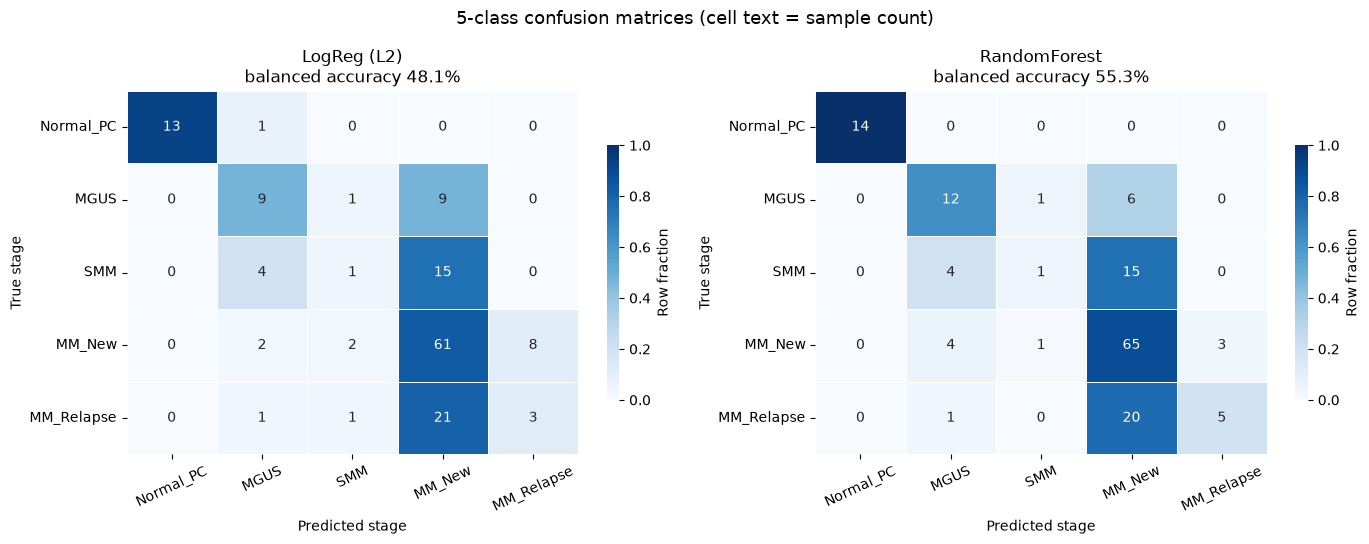

Saved results/ml/cv_predictions_5class.csv


In [10]:
fig, axes = plt.subplots(1, len(multi_out), figsize=(7 * len(multi_out), 5.5))
axes = np.atleast_1d(axes)

for ax, (name, pred) in zip(axes, multi_out.items()):
    cm   = confusion_matrix(y_5, pred, labels=ORDER)
    frac = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(frac, cmap="Blues", vmin=0, vmax=1,
                annot=cm, fmt="d", linewidths=0.6, linecolor="white",
                xticklabels=ORDER, yticklabels=ORDER,
                cbar_kws={"label": "Row fraction", "shrink": 0.7}, ax=ax)
    bacc = balanced_accuracy_score(y_5, pred)
    ax.set_title(f"{name}\nbalanced accuracy {bacc:.1%}")
    ax.set_xlabel("Predicted stage")
    ax.set_ylabel("True stage")
    ax.tick_params(axis="x", rotation=25)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("5-class confusion matrices (cell text = sample count)", fontsize=13)
plt.tight_layout()
plt.savefig("results/figures/ml_confusion_5class.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({"sample": expr_clean.columns, "true_stage": y_5,
              **{f"pred_{n}": p for n, p in multi_out.items()}}
             ).to_csv("results/ml/cv_predictions_5class.csv", index=False)
print("Saved results/ml/cv_predictions_5class.csv")

---
## Feature importance & confound check

The models below are re-fit on all 152 samples **purely to rank genes**. Those rankings are descriptive;
the accuracy numbers from Section 4 and 5 remain the only valid performance estimates.

**The check that matters.** The purity analysis in `analysis.ipynb` established that Normal_PC bone marrow
carries far more contaminating granulocytes than diseased marrow (Mann-Whitney *p* = 1.34e-05). So a
classifier separating Normal_PC from disease could be detecting **sample composition rather than
plasma-cell biology** — a real cell-type difference in the aspirate, not a disease mechanism. The cell
below counts how many of the top-ranked genes are granulocyte markers versus cell-cycle genes, which
distinguishes the two explanations.

**A note on `results/pathway_signature_scores.csv`:** those 4 scores are *not* valid ML features for
predicting stage. Their leading-edge gene lists were chosen by a GSEA run on the SMM → MM_New comparison,
which used the stage labels — so the labels are baked into the features and any model trained on them
would report inflated accuracy. Scoring against the *full* Hallmark gene sets instead of the leading-edge
subset would avoid this, since Hallmark is defined externally and independently of this dataset.

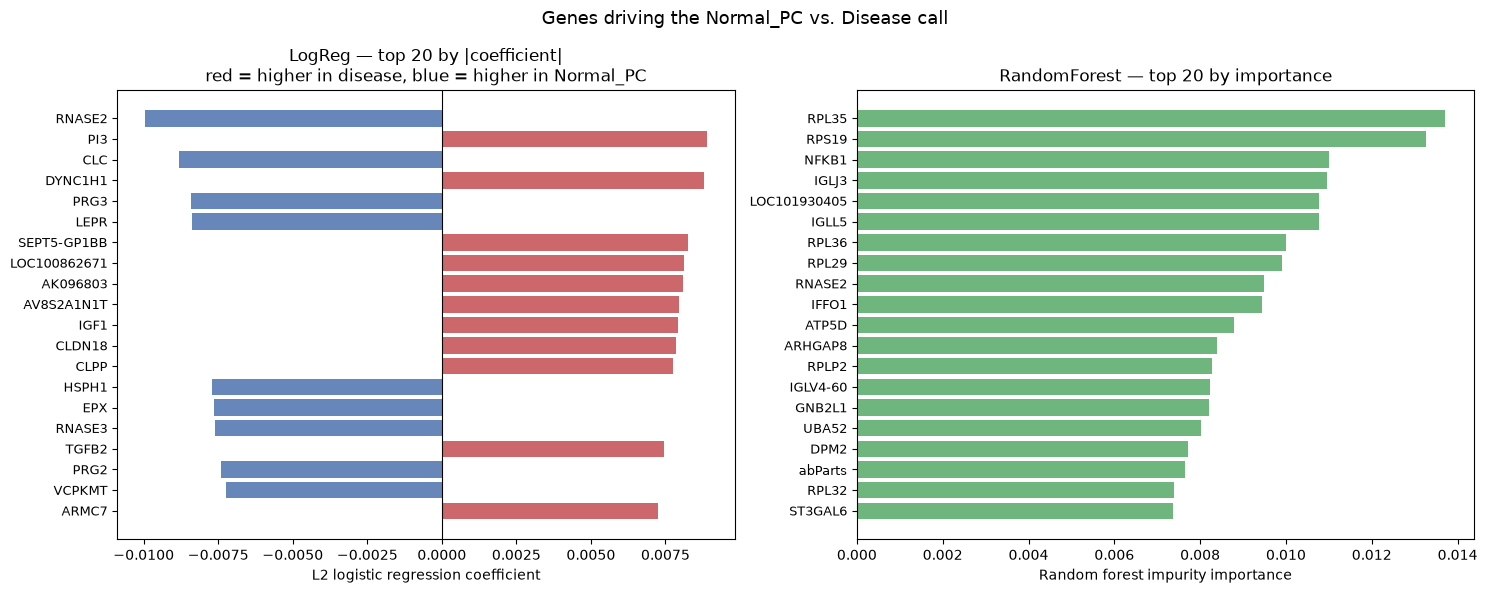

Saved results/ml/feature_importance_binary.csv


In [11]:
lr_full = Pipeline([
    ("sc",  StandardScaler()),
    ("clf", LogisticRegression(C=0.1, max_iter=5000,
                               class_weight="balanced", random_state=SEED)),
]).fit(X_all, y_bin)

rf_full = RandomForestClassifier(n_estimators=500, class_weight="balanced",
                                 random_state=SEED, n_jobs=-1).fit(X_all, y_bin)

genes   = expr_clean.index.to_numpy()
lr_coef = pd.Series(lr_full.named_steps["clf"].coef_[0], index=genes)
rf_imp  = pd.Series(rf_full.feature_importances_,        index=genes)

top_lr = lr_coef.reindex(lr_coef.abs().nlargest(20).index)
top_rf = rf_imp.nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cols = ["#C44E52" if v > 0 else "#4C72B0" for v in top_lr.values]
axes[0].barh(range(len(top_lr)), top_lr.values, color=cols, alpha=0.85)
axes[0].set_yticks(range(len(top_lr)))
axes[0].set_yticklabels(top_lr.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("L2 logistic regression coefficient")
axes[0].set_title("LogReg — top 20 by |coefficient|\nred = higher in disease, blue = higher in Normal_PC")

axes[1].barh(range(len(top_rf)), top_rf.values, color="#55A868", alpha=0.85)
axes[1].set_yticks(range(len(top_rf)))
axes[1].set_yticklabels(top_rf.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("Random forest impurity importance")
axes[1].set_title("RandomForest — top 20 by importance")

plt.suptitle("Genes driving the Normal_PC vs. Disease call", fontsize=13)
plt.tight_layout()
plt.savefig("results/figures/ml_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({"lr_coef": lr_coef, "rf_importance": rf_imp}).to_csv(
    "results/ml/feature_importance_binary.csv")
print("Saved results/ml/feature_importance_binary.csv")

In [12]:
GRANULOCYTE_MARKERS = ["ELANE", "MPO", "PRTN3", "CTSG", "RNASE2", "RNASE3",
                       "PRG2", "CLC", "S100A8", "S100A9", "FCGR3B", "ITGAM"]
CELL_CYCLE_GENES    = ["CCND1", "MYC", "TOP2A", "MKI67", "CCNB2", "CDK1",
                       "AURKA", "PLK1", "BIRC5", "E2F1", "PCNA", "TYMS"]

for label, ranking in [("LogReg |coef|", lr_coef.abs()), ("RandomForest", rf_imp)]:
    top50 = set(ranking.nlargest(50).index)
    gran  = sorted(top50 & set(GRANULOCYTE_MARKERS))
    cycle = sorted(top50 & set(CELL_CYCLE_GENES))
    print(f"--- {label}: top-50 gene overlap ---")
    print(f"  Granulocyte markers ({len(gran)}/{len(GRANULOCYTE_MARKERS)}): {gran if gran else 'none'}")
    print(f"  Cell-cycle genes    ({len(cycle)}/{len(CELL_CYCLE_GENES)}): {cycle if cycle else 'none'}")
    print()

print("Interpretation guide")
print("-" * 60)
print("Granulocyte markers dominate -> the classifier is largely reading sample")
print("  composition (aspirate purity), not plasma-cell disease biology. The")
print("  prediction may still be accurate, but it is not a disease mechanism.")
print()
print("Cell-cycle genes dominate    -> the classifier is reading proliferation,")
print("  consistent with the E2F/MYC/G2-M pathway signal found by GSEA.")
print()
print("Neither dominates            -> the signal is spread across many genes;")
print("  inspect the top-20 plot above and check ranking stability before")
print("  treating any single gene as a biomarker candidate.")

--- LogReg |coef|: top-50 gene overlap ---
  Granulocyte markers (4/12): ['CLC', 'PRG2', 'RNASE2', 'RNASE3']
  Cell-cycle genes    (0/12): none

--- RandomForest: top-50 gene overlap ---
  Granulocyte markers (1/12): ['RNASE2']
  Cell-cycle genes    (0/12): none

Interpretation guide
------------------------------------------------------------
Granulocyte markers dominate -> the classifier is largely reading sample
  composition (aspirate purity), not plasma-cell disease biology. The
  prediction may still be accurate, but it is not a disease mechanism.

Cell-cycle genes dominate    -> the classifier is reading proliferation,
  consistent with the E2F/MYC/G2-M pathway signal found by GSEA.

Neither dominates            -> the signal is spread across many genes;
  inspect the top-20 plot above and check ranking stability before
  treating any single gene as a biomarker candidate.


---
## Caveats

- **Small classes.** With 14 Normal_PC, 19 MGUS and 20 SMM samples, 5-fold CV leaves only 3-4 samples of
  the rarest class per fold. Every metric here carries wide uncertainty; treat differences of a few
  percent between models as noise, not as one model beating another.
- **No held-out test set.** Cross-validation on 152 samples is the honest ceiling for a dataset this size,
  but hyperparameters (`C=0.1`, 500 trees) were fixed a priori rather than tuned — tuning them against
  these same CV folds would optimistically bias the scores.
- **Feature rankings are unstable** when genes outnumber samples ~87:1. Correlated genes trade places
  between runs. Treat the top-20 lists as a shortlist to investigate, not a validated biomarker panel.
- **Single cohort, single platform.** Any candidate gene needs replication in an independent dataset on
  different hardware before it means anything.

In [13]:
from sklearn.base import clone
from sklearn.metrics import cohen_kappa_score, mean_absolute_error
from scipy.stats import spearmanr

STAGE_TO_IDX = {s: i for i, s in enumerate(ORDER)}
y_idx        = np.array([STAGE_TO_IDX[s] for s in y_5])
K_STAGES     = len(ORDER)

base_ord = Pipeline([
    ("clf", RandomForestClassifier(n_estimators=500, class_weight="balanced",
                                   random_state=SEED, n_jobs=-1)),
])
cv_ord = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Each binary model is fit on training folds only, so no leakage.
P_gt = np.zeros((len(y_idx), K_STAGES - 1))
for fold, (tr, te) in enumerate(cv_ord.split(X_all, y_5), start=1):
    for k in range(K_STAGES - 1):
        yk = (y_idx > k).astype(int)
        P_gt[te, k] = clone(base_ord).fit(X_all[tr], yk[tr]).predict_proba(X_all[te])[:, 1]
    print(f"  fold {fold}/5 done", flush=True)

# Expected number of thresholds crossed = position on the disease timeline
prog_score = P_gt.sum(axis=1)
pred_ord   = np.clip(np.rint(prog_score), 0, K_STAGES - 1).astype(int)

def ordinal_metrics(true_idx, pred_idx, label):
    return {
        "model":           label,
        "exact_acc":       (true_idx == pred_idx).mean(),
        "adjacent_acc":    (np.abs(true_idx - pred_idx) <= 1).mean(),
        "MAE_stages":      mean_absolute_error(true_idx, pred_idx),
        "quadratic_kappa": cohen_kappa_score(true_idx, pred_idx, weights="quadratic"),
        "spearman_rho":    spearmanr(true_idx, pred_idx)[0],
    }

nominal_idx = np.array([STAGE_TO_IDX[s] for s in multi_out["RandomForest"]])
const_idx   = np.full_like(y_idx, STAGE_TO_IDX["MM_New"])

ord_cmp = pd.DataFrame([
    ordinal_metrics(y_idx, const_idx,   "Baseline (always MM_New)"),
    ordinal_metrics(y_idx, nominal_idx, "Nominal RF (Section 5)"),
    ordinal_metrics(y_idx, pred_ord,    "Ordinal RF (Frank-Hall)"),
]).set_index("model")

print()
print("Ordinal comparison - MAE is in units of stages (lower is better)")
print(ord_cmp.round(3).to_string())
print()
print("Per-threshold separability (how cleanly is each boundary crossed?)")
for k in range(K_STAGES - 1):
    auc = roc_auc_score((y_idx > k).astype(int), P_gt[:, k])
    left, right = " + ".join(ORDER[:k + 1]), " + ".join(ORDER[k + 1:])
    flag = "  <-- weakest" if auc < 0.75 else ""
    print(f"  [{left}]  vs  [{right}]".ljust(62) + f"AUC {auc:.3f}{flag}")

smm_pred = pd.Series(pred_ord[y_idx == STAGE_TO_IDX["SMM"]]).map(dict(enumerate(ORDER)))
print()
print("Where do the 20 SMM samples land now?")
print(smm_pred.value_counts().reindex(ORDER).fillna(0).astype(int).to_string())

ord_cmp.to_csv("results/ml/ordinal_comparison.csv")
pd.DataFrame({"sample": expr_clean.columns, "true_stage": y_5,
              "progression_score": prog_score,
              "pred_ordinal": [ORDER[i] for i in pred_ord]}
             ).to_csv("results/ml/ordinal_predictions.csv", index=False)
print()
print("Saved results/ml/ordinal_comparison.csv and ordinal_predictions.csv")


  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done

Ordinal comparison - MAE is in units of stages (lower is better)
                          exact_acc  adjacent_acc  MAE_stages  quadratic_kappa  spearman_rho
model                                                                                       
Baseline (always MM_New)      0.480         0.783       0.829            0.000           NaN
Nominal RF (Section 5)        0.638         0.928       0.441            0.763         0.666
Ordinal RF (Frank-Hall)       0.480         0.947       0.572            0.650         0.612

Per-threshold separability (how cleanly is each boundary crossed?)
  [Normal_PC]  vs  [MGUS + SMM + MM_New + MM_Relapse]         AUC 1.000
  [Normal_PC + MGUS]  vs  [SMM + MM_New + MM_Relapse]         AUC 0.936
  [Normal_PC + MGUS + SMM]  vs  [MM_New + MM_Relapse]         AUC 0.900
  [Normal_PC + MGUS + SMM + MM_New]  vs  [MM_Relapse]         AUC 0.750

Where do the 20 SMM samples land

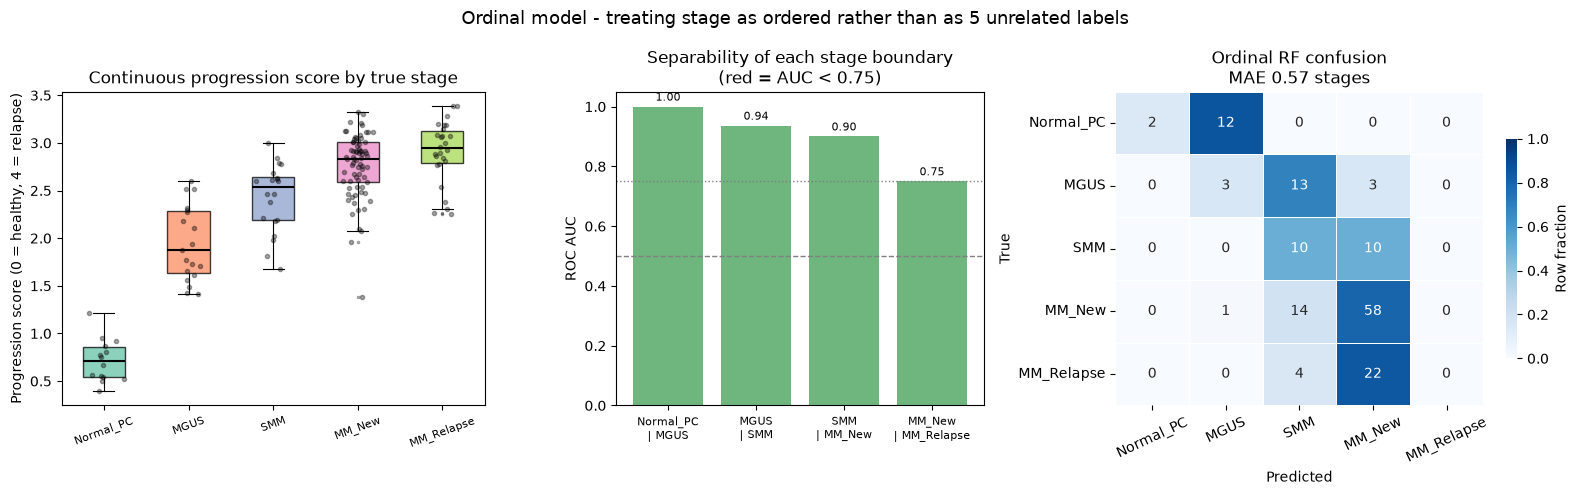

Saved results/figures/ml_ordinal.png


In [14]:
fig = plt.figure(figsize=(16, 5))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.15, 1, 1.25])

ax = fig.add_subplot(gs[0, 0])
data = [prog_score[y_idx == i] for i in range(K_STAGES)]
bp = ax.boxplot(data, patch_artist=True, tick_labels=ORDER,
                medianprops=dict(color="black", lw=1.5),
                whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
                flierprops=dict(marker=".", ms=3, alpha=0.4))
for patch, stg in zip(bp["boxes"], ORDER):
    patch.set_facecolor(PALETTE[stg]); patch.set_alpha(0.75)
rng = np.random.default_rng(3)
for i in range(K_STAGES):
    v = data[i]
    ax.scatter(np.full(len(v), i + 1) + rng.normal(0, 0.07, len(v)), v,
               color="black", s=9, alpha=0.35, zorder=3)
ax.set_ylabel("Progression score (0 = healthy, 4 = relapse)")
ax.set_title("Continuous progression score by true stage")
ax.tick_params(axis="x", labelsize=8, rotation=20)

ax = fig.add_subplot(gs[0, 1])
aucs   = [roc_auc_score((y_idx > k).astype(int), P_gt[:, k]) for k in range(K_STAGES - 1)]
labels = [f"{ORDER[k]}\n| {ORDER[k+1]}" for k in range(K_STAGES - 1)]
cols   = ["#C44E52" if a < 0.75 else "#55A868" for a in aucs]
ax.bar(range(len(aucs)), aucs, color=cols, alpha=0.85)
ax.axhline(0.5,  color="grey", ls="--", lw=1)
ax.axhline(0.75, color="grey", ls=":",  lw=1)
ax.set_xticks(range(len(aucs))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("ROC AUC")
ax.set_title("Separability of each stage boundary\n(red = AUC < 0.75)")
for i, a in enumerate(aucs):
    ax.text(i, a + 0.02, f"{a:.2f}", ha="center", fontsize=8)

ax = fig.add_subplot(gs[0, 2])
cm   = confusion_matrix(y_idx, pred_ord, labels=range(K_STAGES))
frac = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
sns.heatmap(frac, cmap="Blues", vmin=0, vmax=1, annot=cm, fmt="d",
            linewidths=0.6, linecolor="white",
            xticklabels=ORDER, yticklabels=ORDER,
            cbar_kws={"label": "Row fraction", "shrink": 0.7}, ax=ax)
ax.set_title(f"Ordinal RF confusion\nMAE {ord_cmp.loc['Ordinal RF (Frank-Hall)', 'MAE_stages']:.2f} stages")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=25); ax.tick_params(axis="y", rotation=0)

plt.suptitle("Ordinal model - treating stage as ordered rather than as 5 unrelated labels", fontsize=13)
plt.tight_layout()
plt.savefig("results/figures/ml_ordinal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results/figures/ml_ordinal.png")


---
## Purity-corrected re-analysis

39% of the down-regulated Normal_PC → MGUS signal (94 of 238 genes) tracks the granulocyte contamination
score. This section removes those 94 genes plus the 12-marker panel itself, then re-runs the pathway
enrichment to see which conclusions survive.

**What each outcome would mean:**

| Result | Interpretation |
|---|---|
| Complement / TNF-NF-kB / Inflammatory all **lose** significance | That transition was largely a sample-composition artefact and must be reported as such |
| Some pathways **survive** with similar NES | There is genuine early-transformation biology underneath the contamination |
| Pathways appear as **NEW** | The contamination was masking a real signal |

Note that per-gene t-tests barely change when genes are removed — only the Benjamini-Hochberg correction
shifts, since there are fewer tests. The pathway re-run is the real test, because GSEA ranks *all* genes
and the granulocyte genes were the strongest contributors to those negative enrichment scores.


In [15]:
_flag   = pd.read_csv("results/Normal_PC_vs_MGUS_DE.csv", index_col=0)
EXCLUDE = sorted((set(_flag.index[_flag["purity_flag"]]) | set(GRANULOCYTE_MARKERS))
                 & set(expr_clean.index))

expr_pure = expr_clean.drop(index=EXCLUDE)
print(f"Genes excluded (purity-flagged + marker panel): {len(EXCLUDE)}")
print(f"Matrix after exclusion: {expr_pure.shape[0]:,} genes x {expr_pure.shape[1]} samples")
print()

de_pure  = run_de(expr_pure, meta_clean, STAGE_COL, "Normal_PC", "MGUS")
rnk_pure = de_pure["log2FC"].dropna().sort_values(ascending=False)

print("Re-running pre-ranked GSEA on the purity-filtered ranking...", flush=True)
res_pure = gp.prerank(rnk=rnk_pure, gene_sets="MSigDB_Hallmark_2020", threads=1,
                      min_size=15, max_size=500, permutation_num=100,
                      seed=SEED if "SEED" in dir() else 42, verbose=False)
pure = res_pure.res2d.set_index("Term")

orig = pd.read_csv("results/pathways/Normal_PC_vs_MGUS_GSEA_Hallmark.csv").set_index("Term")

cmp = pd.DataFrame({
    "NES_before": orig["NES"].astype(float),
    "FDR_before": orig["FDR q-val"].astype(float),
    "NES_after":  pure["NES"].astype(float),
    "FDR_after":  pure["FDR q-val"].astype(float),
}).dropna()
cmp["dNES"]       = cmp["NES_after"] - cmp["NES_before"]
cmp["sig_before"] = cmp["FDR_before"] < 0.25
cmp["sig_after"]  = cmp["FDR_after"]  < 0.25
cmp["verdict"]    = np.select(
    [ cmp["sig_before"] & ~cmp["sig_after"],
      cmp["sig_before"] &  cmp["sig_after"],
     ~cmp["sig_before"] &  cmp["sig_after"]],
    ["LOST significance", "survived", "NEW"], default="ns both")

print()
print(f"Significant before (FDR<0.25): {cmp['sig_before'].sum()}")
print(f"Significant after            : {cmp['sig_after'].sum()}")
print(f"  survived : {(cmp['verdict']=='survived').sum()}")
print(f"  LOST     : {(cmp['verdict']=='LOST significance').sum()}")
print(f"  NEW      : {(cmp['verdict']=='NEW').sum()}")
print()
print("Pathways significant before the purity filter, ranked by NES change:")
show = cmp[cmp["sig_before"]].sort_values("dNES", ascending=False)
print(show[["NES_before","NES_after","dNES","FDR_after","verdict"]].round(3).to_string())

cmp.to_csv("results/pathways/Normal_PC_vs_MGUS_GSEA_purity_corrected.csv")
de_pure.to_csv("results/Normal_PC_vs_MGUS_DE_purity_corrected.csv")
print()
print("Saved purity-corrected DE and GSEA comparison")


Genes excluded (purity-flagged + marker panel): 97
Matrix after exclusion: 13,140 genes x 152 samples



NameError: name 'run_de' is not defined